In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
!pip install -q kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0


In [3]:
!unzip "flickr8k.zip" -d "/content/dataset/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Images/2844963839_ff09cdb81f.jpg  
  inflating: /content/dataset/Images/2845246160_d0d1bbd6f0.jpg  
  inflating: /content/dataset/Images/2845691057_d4ab89d889.jpg  
  inflating: /content/dataset/Images/2845845721_d0bc113ff7.jpg  
  inflating: /content/dataset/Images/2846037553_1a1de50709.jpg  
  inflating: /content/dataset/Images/2846785268_904c5fcf9f.jpg  
  inflating: /content/dataset/Images/2846843520_b0e6211478.jpg  
  inflating: /content/dataset/Images/2847514745_9a35493023.jpg  
  inflating: /content/dataset/Images/2847615962_c330bded6e.jpg  
  inflating: /content/dataset/Images/2847859796_4d9cb0d31f.jpg  
  inflating: /content/dataset/Images/2848266893_9693c66275.jpg  
  inflating: /content/dataset/Images/2848571082_26454cb981.jpg  
  inflating: /content/dataset/Images/2848895544_6d06210e9d.jpg  
  inflating: /content/dataset/Images/2848977044_446a31d86e.jpg  
  inflating: /content/dataset/Images/28

In [4]:
df = pd.read_csv("dataset/captions.txt")
df.head(10)

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


In [5]:
df.shape # 31783 images x 5 descriptions for each image

(40455, 2)

In [6]:
!pip install tensorflow

In [7]:
!pip install opencv-python

In [8]:
import tensorflow as tf
import cv2

In [9]:
def read_image(image_name, image_folder="dataset/Images"):
    """
    Reads an image from the specified folder and returns it as an array.
    """
    img_path = os.path.join(image_folder, image_name)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Unable to read {image_name}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB format
    return img

In [10]:
def display_image_with_captions(image_name, captions_df, image_folder="dataset/Images"):
    """
    Reads and displays an image with all 5 captions.
    """
    # Read image
    img = read_image(image_name, image_folder)
    if img is None:
        return

    # Get all comments for this image
    comments = captions_df[captions_df["image"] == image_name]["caption"].tolist()

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

    # Show captions below the image
    caption_text = "\n".join(comments)  # Join comments as multi-line text
    plt.title(caption_text, fontsize=10, loc='center', pad=10)
    plt.show()

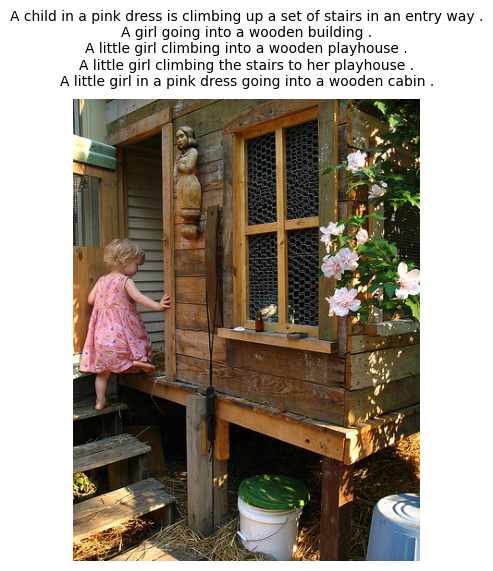

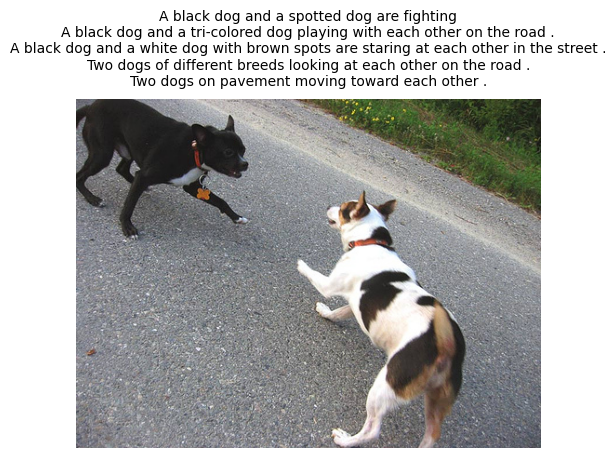

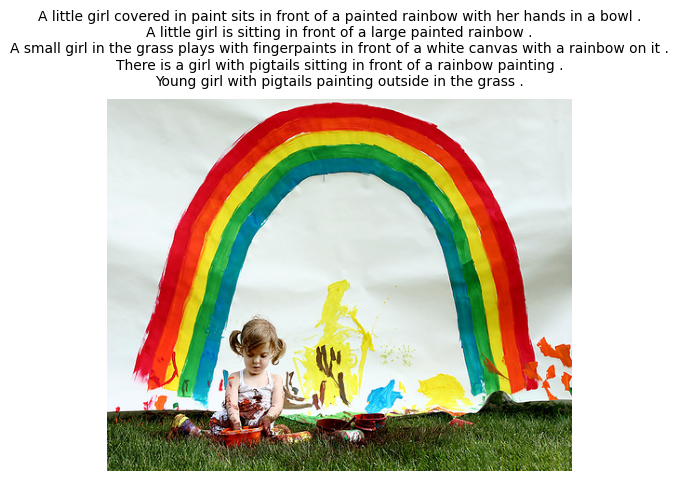

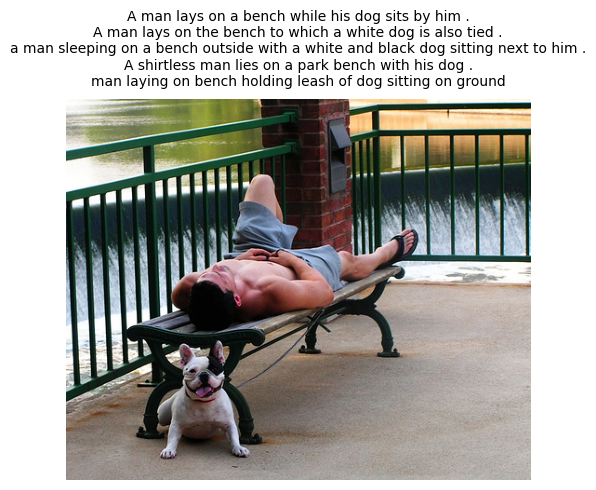

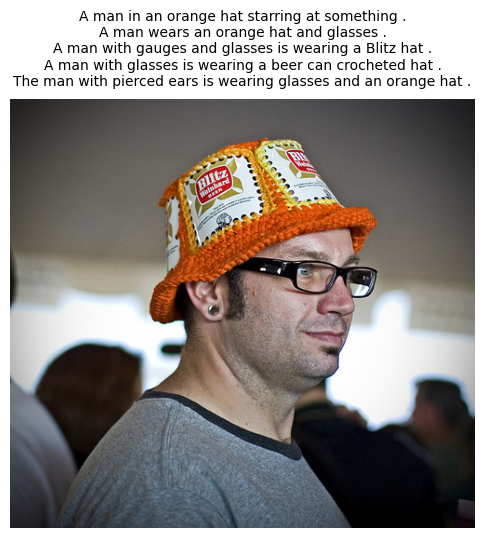

In [11]:
# Display first 5 images with their 5 captions each
for image_name in df["image"].unique()[:5]:
    display_image_with_captions(image_name, df)


In [12]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 10.3 MB/s eta 0:00:00


In [13]:
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from contractions import fix

# Download necessary NLTK data
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [14]:
def preprocess_caption(text):
    # 1️⃣ Convert to lowercase
    text = text.lower()

    # 2️⃣ Expand contractions (e.g., "can't" → "cannot")
    text = fix(text)

    # 3️⃣ Remove special characters, numbers, and punctuations
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Keep only letters and spaces

    # 4️⃣ Tokenize words
    words = word_tokenize(text)

    # 6️⃣ Remove single-character words
    words = [word for word in words if len(word) > 1]

    # 7️⃣ Lemmatization (convert words to base form, e.g., "running" → "run")
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    # 8️⃣ Join words back into a sentence
    cleaned_text = " ".join(words)

    # 9️⃣ Remove extra spaces
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

    return cleaned_text  # Removed adding <start> and <end> here

In [15]:
# Apply preprocessing function to all captions
df["caption"] = df["caption"].apply(preprocess_caption)
df['caption'] = "startseq "+df['caption']+" endseq"

In [16]:
df['caption'].values[:5]

array(['startseq child in pink dress is climbing up set of stair in an entry way endseq',
       'startseq girl going into wooden building endseq',
       'startseq little girl climbing into wooden playhouse endseq',
       'startseq little girl climbing the stair to her playhouse endseq',
       'startseq little girl in pink dress going into wooden cabin endseq'],
      dtype=object)

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [18]:
captions = df['caption'].tolist()
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

images = df['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = df[df['image'].isin(train_images)]
test = df[df['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

tokenizer.texts_to_sequences([captions[1]])[0]

[1, 14, 314, 66, 193, 105, 2]

In [19]:
captions[1]

'startseq girl going into wooden building endseq'

In [20]:
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model

# 🔹 Load Pretrained EfficientNetB5 Model (without classification layers)
base_model = EfficientNetB5(weights="imagenet", include_top=False, pooling='avg')
model = Model(inputs=base_model.input, outputs=base_model.output)  # Extract features from the last conv layer

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [21]:
# 🔹 Folder Paths
image_folder = "dataset/Images"   # Path to original images
save_folder = "dataset/efnet_features"  # Path to save extracted features
os.makedirs(save_folder, exist_ok=True)

# 🔹 Get Image Filenames
image_filenames = sorted(os.listdir(image_folder))

# 🔹 Set Batch Size for Efficient Processing
batch_size = 32
image_features = {}

# 🔹 Process Images in Batches
num_images = len(image_filenames)
for i in range(0, num_images, batch_size):
    batch_files = image_filenames[i:i+batch_size]  # Select batch filenames
    batch_images = []

    # 🔹 Load and Preprocess Images
    for img_name in batch_files:
        img_path = os.path.join(image_folder, img_name)
        img = cv2.imread(img_path)  # Read image

        if img is None:
            print(f"⚠️ Warning: {img_path} not found, skipping...")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        img = cv2.resize(img, (456, 456))  # Resize for EfficientNetB5
        img = preprocess_input(img.astype(np.float32))  # Normalize
        batch_images.append(img)

    if not batch_images:
        continue  # Skip empty batches

    batch_images = np.array(batch_images)  # Convert list to numpy array

    # 🔹 Extract Features in Batches
    batch_features = model.predict(batch_images)  # Shape: (batch_size, 512)

    # Store extracted features
    for j, img_name in enumerate(batch_files):
        image_features[img_name] = batch_features[j]

    print(f"✅ Processed {i+len(batch_files)}/{num_images} images.")

print(f"🎯 Feature extraction complete! Extracted {len(image_features)} feature vectors.")

# Save extracted features as a NumPy file for later use
features_path = "dataset/image_features.npy"
np.save(features_path, image_features)
print(f"💾 Features saved to '{features_path}'")


1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step
✅ Processed 32/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
✅ Processed 64/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
✅ Processed 96/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
✅ Processed 128/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
✅ Processed 160/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
✅ Processed 192/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
✅ Processed 224/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
✅ Processed 256/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
✅ Processed 288/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
✅ Processed 320/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
✅ Processed 352/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
✅ Processed 384/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
✅ Processed 416/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
✅ Processed 448/8091 images.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
✅ Processed 4

In [22]:
from tensorflow.keras.utils import Sequence , to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [23]:
features = np.load("dataset/image_features.npy", allow_pickle=True).item()  # ✅ Convert back to dictionary

class CustomDataGenerator(Sequence):

    def __init__(self, df, X_col, y_col, batch_size, features, max_length, vocab_size, tokenizer, shuffle=True):
        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col  # Already tokenized captions
        self.batch_size = batch_size
        self.features = features  # Dictionary mapping image filenames to feature arrays
        print(f"Type of self.features: {type(self.features)}")
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.tokenizer = tokenizer  # Pass the tokenizer to the generator
        self.shuffle = shuffle
        self.n = len(self.df)

        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def on_epoch_end(self):
        """ Shuffle dataset at the end of each epoch """
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __len__(self):
        """ Number of batches per epoch """
        return self.n // self.batch_size

    def __getitem__(self, index):
        """ Generate batch data """
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size, :]
        X1, X2, y = self.__get_data(batch)
        return (X1, X2), y

    def __get_data(self, batch):
        """ Generates X1 (image features), X2 (captions), and y (next words) """
        X1, X2, y = [], [], []

        for _, row in batch.iterrows():
            image = row[self.X_col]
            feature = self.features.get(image, None)  # Fetch image feature

            if feature is None:
                print(f"⚠️ Warning: No feature found for {image}, skipping...")
                continue  # Skip missing features

            caption = row[self.y_col]  # Get the caption string
            tokenized_caption = self.tokenizer.texts_to_sequences([caption])[0]  # Tokenize the caption here

            for i in range(1, len(tokenized_caption)):  # Create training samples
                X1.append(feature)
                X2.append(tokenized_caption[:i])  # Partial sequence as input
                y.append(tokenized_caption[i])    # Next word as output

        # Convert to NumPy arrays
        X1 = np.array(X1)
        X2 = pad_sequences(X2, maxlen=self.max_length, padding="post")  # Ensure uniform sequence length
        y = to_categorical(y, num_classes=self.vocab_size)  # One-hot encode output words

        return X1, X2, y

In [24]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class Attention(Layer):
    def __init__(self, units):
        super(Attention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

In [25]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout, Bidirectional, BatchNormalization, LayerNormalization

# Define model parameters
EMBEDDING_DIM = 512
LSTM_UNITS = 512
DROPOUT_RATE = 0.4

# CNN Encoder
image_input = Input(shape=(2048,))  # Feature vector from CNN
image_features = Dense(LSTM_UNITS, activation="relu")(image_input)
image_features = BatchNormalization()(image_features)  # ? Normalizing CNN features
image_features = Dropout(DROPOUT_RATE)(image_features)

# Caption Decoder (BiLSTM)
caption_input = Input(shape=(max_length,))
caption_embedding = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(caption_input)
caption_embedding = LayerNormalization()(caption_embedding)  # ? LayerNormalization instead of BatchNorm
caption_embedding = Dropout(DROPOUT_RATE)(caption_embedding)

# BiLSTM Layer
bilstm_layer = Bidirectional(LSTM(LSTM_UNITS, return_sequences=False, return_state=True, dropout=DROPOUT_RATE))
lstm_output, forward_h, forward_c, backward_h, backward_c = bilstm_layer(caption_embedding)

# Normalize only the Dense output, not the LSTM output
hidden_state = tf.keras.layers.Concatenate()([forward_h, backward_h])  # Merging forward & backward LSTM states

# Merge Image Features & LSTM Output
merged = tf.keras.layers.Concatenate()([hidden_state, image_features])
merged = BatchNormalization()(merged)  # ? Batch Normalization after merging
merged = Dropout(DROPOUT_RATE)(merged)

# Fully Connected Layer
output = Dense(vocab_size, activation="softmax")(merged)

# Define Model
model = tf.keras.models.Model(inputs=[image_input, caption_input], outputs=output)

# Compile Model
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam")

# Print Model Summary
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 34)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 34, 512)        │      3,868,672 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 34, 512)        │          1,024 │ embedding[0][0]        │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 2048)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 34, 512)        │              0 │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal (NotEqual)      │ (None, 34)             │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 512)            │      1,049,088 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ [(None, 1024), (None,  │      4,198,400 │ dropout_1[0][0],       │
│ (Bidirectional)           │ 512), (None, 512),     │                │ not_equal[0][0]        │
│                           │ (None, 512), (None,    │                │                        │
│                           │ 512)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 512)            │          2,048 │ dense[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 1024)           │              0 │ bidirectional[0][1],   │
│                           │                        │                │ bidirectional[0][3]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 512)            │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 1536)           │              0 │ concatenate[0][0],     │
│ (Concatenate)             │                        │                │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 1536)           │          6,144 │ concatenate_1[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 1536)           │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)      

 Total params: 20,738,948 (79.11 MB)

 Trainable params: 20,734,852 (79.10 MB)

 Non-trainable params: 4,096 (16.00 KB)

None


In [26]:
image_path = 'dataset/preprocessed_images'
train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=32
                                      ,vocab_size=vocab_size,max_length=max_length,features=features,tokenizer=tokenizer)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=32,
                                           vocab_size=vocab_size,max_length=max_length,features=features,tokenizer=tokenizer)

Type of self.features: <class 'dict'>
Type of self.features: <class 'dict'>


In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

In [28]:
model_name = "model.h5"
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            verbose=1)
earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5,
                              verbose = 0, restore_best_weights=True)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=0.00000001)
optimizer = Adam(learning_rate=0.001)
loss_function = CategoricalCrossentropy()

In [29]:
model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=["accuracy"]
)

In [30]:
history = model.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        verbose=1,
        callbacks=[checkpoint,earlystopping,learning_rate_reduction],
        )

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2451 - loss: 4.7549
Epoch 1: val_loss improved from inf to 3.37028, saving model to model.h5


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 92s 78ms/step - accuracy: 0.2451 - loss: 4.7542 - val_accuracy: 0.3348 - val_loss: 3.3703 - learning_rate: 0.0010
Epoch 2/50
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3408 - loss: 3.2152
Epoch 2: val_loss improved from 3.37028 to 3.25378, saving model to model.h5


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 78s 73ms/step - accuracy: 0.3408 - loss: 3.2152 - val_accuracy: 0.3513 - val_loss: 3.2538 - learning_rate: 0.0010
Epoch 3/50
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3671 - loss: 2.8888
Epoch 3: val_loss improved from 3.25378 to 3.22716, saving model to model.h5


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 83s 78ms/step - accuracy: 0.3671 - loss: 2.8888 - val_accuracy: 0.3576 - val_loss: 3.2272 - learning_rate: 0.0010
Epoch 4/50
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3841 - loss: 2.7057
Epoch 4: val_loss improved from 3.22716 to 3.22087, saving model to model.h5


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 80s 74ms/step - accuracy: 0.3841 - loss: 2.7057 - val_accuracy: 0.3575 - val_loss: 3.2209 - learning_rate: 0.0010
Epoch 5/50
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3993 - loss: 2.5621
Epoch 5: val_loss improved from 3.22087 to 3.21040, saving model to model.h5


1074/1074 ━━━━━━━━━━━━━━━━━━━━ 83s 77ms/step - accuracy: 0.3993 - loss: 2.5621 - val_accuracy: 0.3606 - val_loss: 3.2104 - learning_rate: 0.0010
Epoch 6/50
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4115 - loss: 2.4491
Epoch 6: val_loss did not improve from 3.21040
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 136s 71ms/step - accuracy: 0.4115 - loss: 2.4492 - val_accuracy: 0.3618 - val_loss: 3.2356 - learning_rate: 0.0010
Epoch 7/50
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4232 - loss: 2.3628
Epoch 7: val_loss did not improve from 3.21040
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 76s 70ms/step - accuracy: 0.4232 - loss: 2.3629 - val_accuracy: 0.3661 - val_loss: 3.2342 - learning_rate: 0.0010
Epoch 8/50
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4340 - loss: 2.2894
Epoch 8: val_loss did not improve from 3.21040

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.4340 - loss: 2.2894

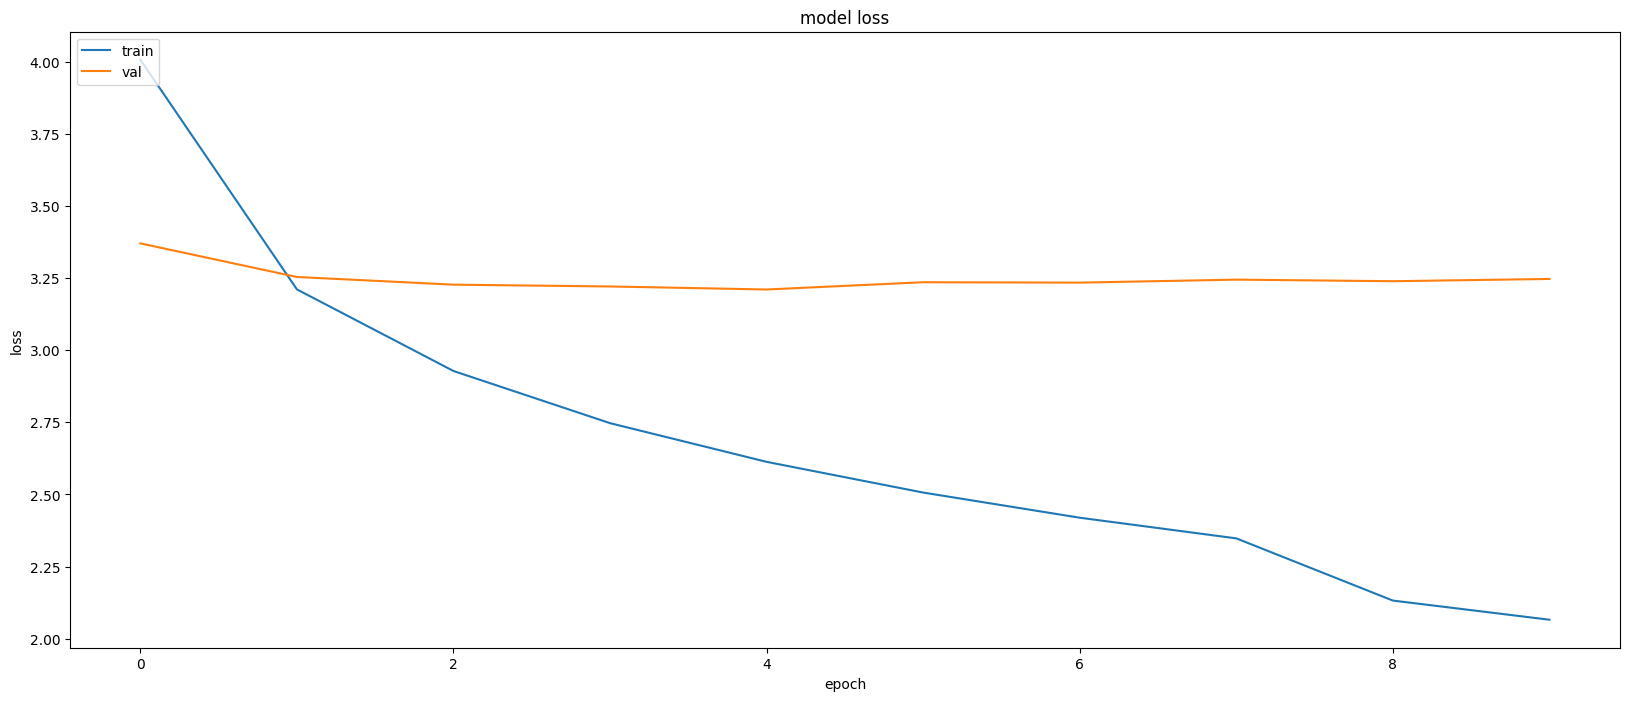

In [31]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

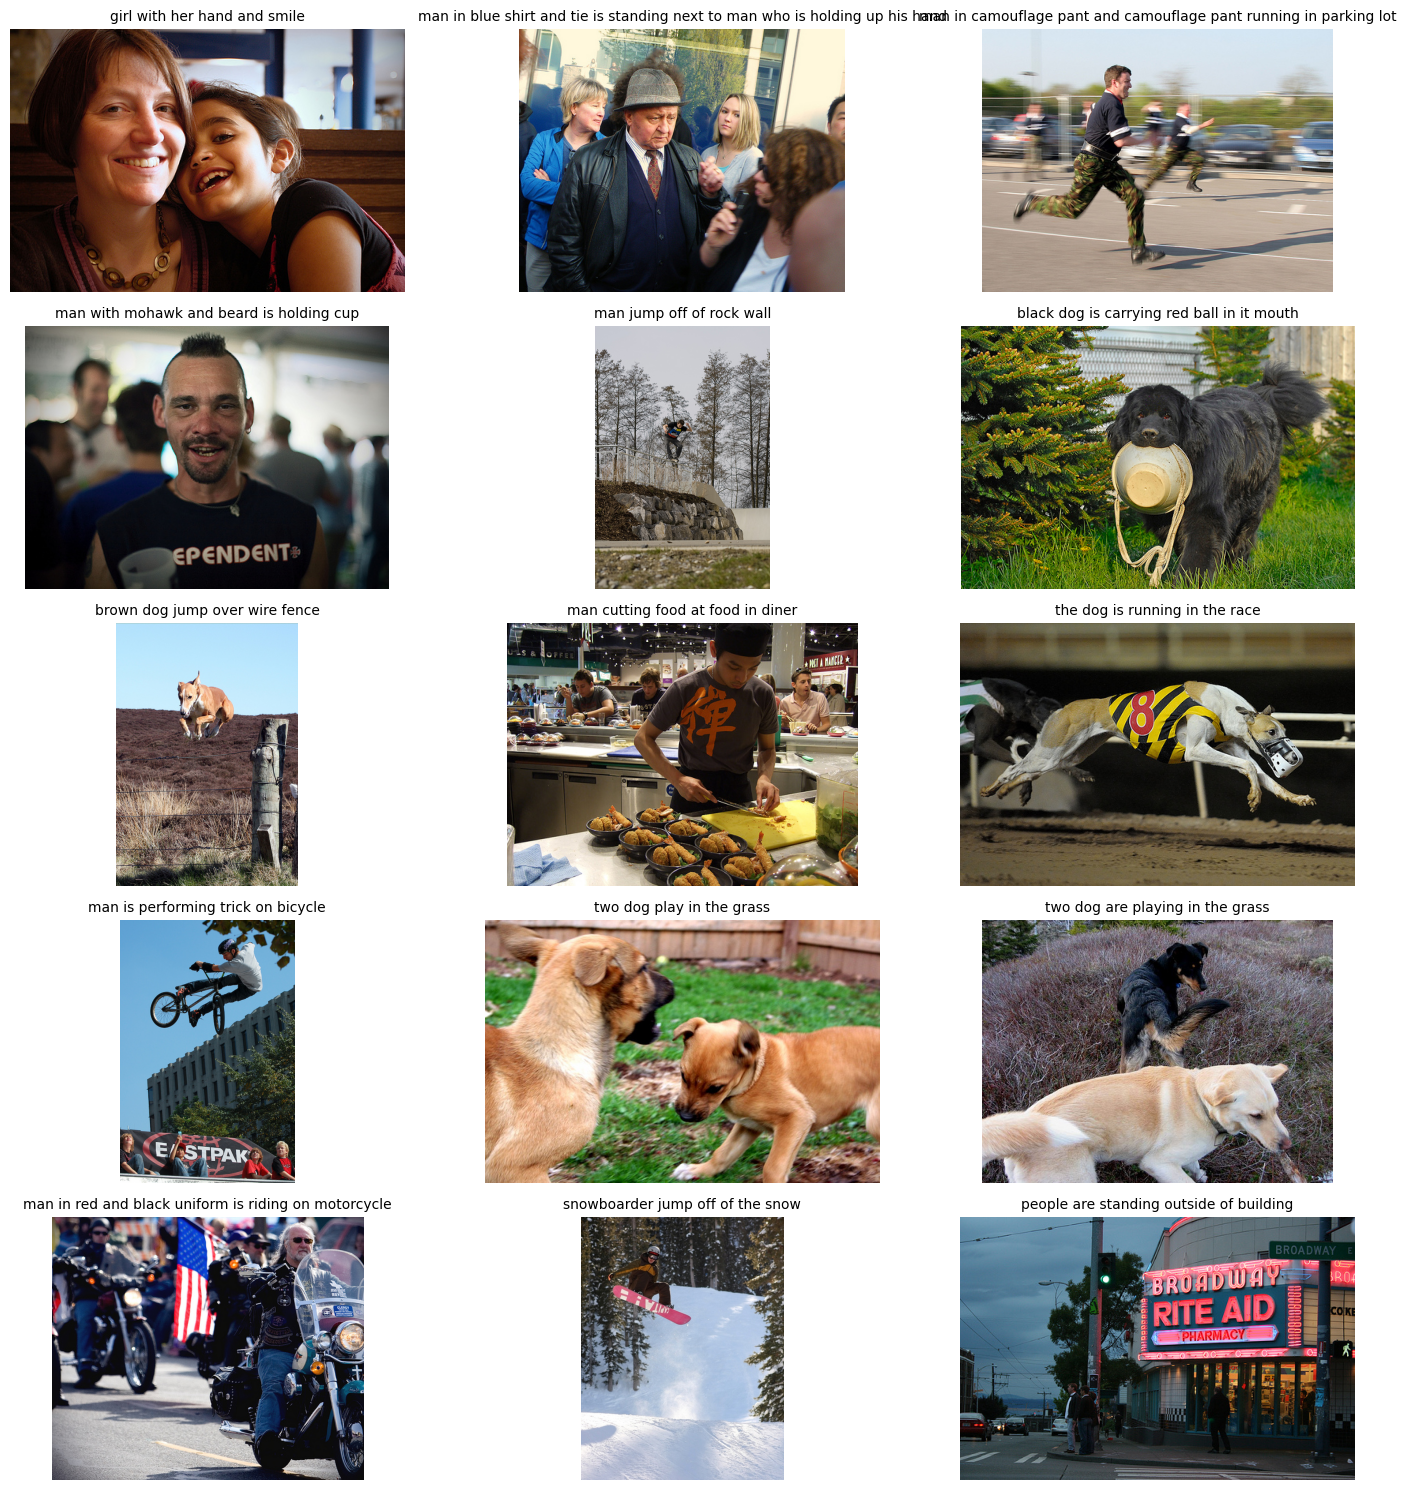

In [53]:
import matplotlib.pyplot as plt
import random
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from PIL import Image

def idx_to_word(index, tokenizer):
    """Convert index to word using the tokenizer's index_word dictionary."""
    return tokenizer.index_word.get(index, None)

def predict_caption(model, image_id, tokenizer, max_length, features):
    """
    Generate a caption for an image using the trained model.

    Parameters:
    - model: Trained image captioning model.
    - image_id: ID of the image (used to retrieve features).
    - tokenizer: Tokenizer for text processing.
    - max_length: Maximum length of the caption.
    - features: Dictionary containing extracted CNN features.

    Returns:
    - Generated caption as a string.
    """

    # Retrieve precomputed image features
    if image_id not in features:
        raise ValueError(f"Image ID {image_id} not found in extracted features.")

    image_feature = features[image_id].reshape(1, 2048)  # Ensure correct shape

    # Start sequence with 'startseq' token (adjust based on your tokenizer)
    in_text = 'startseq'

    for _ in range(max_length):
        # Convert caption text to sequence of indices
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')  # Ensure right-padding

        # Predict the next word
        y_pred = model.predict([image_feature, sequence], verbose=0)
        y_pred = np.argmax(y_pred)  # Get highest probability word index

        # Convert predicted index to word
        word = idx_to_word(y_pred, tokenizer)

        if word is None:  # Skip unknown words
            continue

        # Append the word to the sequence
        in_text += " " + word

        # Stop if the 'endseq' token is predicted (adjust based on your tokenizer)
        if word == 'endseq':
            break

    # Remove 'startseq' and 'endseq' tokens before returning
    final_caption = in_text.replace("startseq", "").replace("endseq", "").strip()
    return final_caption

def display_predictions(model, test_images, tokenizer, max_length, features, num_samples=15):
    """
    Predict captions for randomly selected images from the test set and display them.

    Parameters:
    - model: Trained image captioning model.
    - test_images: List of test image filenames or IDs.
    - tokenizer: Tokenizer for text processing.
    - max_length: Maximum length of captions.
    - features: Dictionary of extracted image features.
    - num_samples: Number of random samples to display (default: 15).
    """

    # Select 15 random images from the test set
    sample_images = random.sample(test_images, num_samples)

    plt.figure(figsize=(15, 15))

    for i, image_id in enumerate(sample_images):
        # Generate caption
        caption = predict_caption(model, image_id, tokenizer, max_length, features)

        # Load and display image
        image_path = f"dataset/Images/{image_id}"  # Modify this path based on dataset structure
        img = Image.open(image_path)

        plt.subplot(5, 3, i + 1)  # Create a 5x3 grid
        plt.imshow(img)
        plt.axis("off")
        plt.title(caption, fontsize=10)

    plt.tight_layout()
    plt.show()

# Example usage
test_images = list(features.keys())  # Assuming 'features' dictionary contains test image IDs
display_predictions(model, test_images, tokenizer, max_length, features)